when building a machine learning model there are 3 steps.
1. perpare the data
- import the data
- explore the data
- split the data- some of the data will be used to test the model while the other to train the model.
2. build the model itself
- baseline- what is the minimum level of performance my model needs to achieve in order to add value
- iterate- build the model, check the model, make adjustments and repeate the process
- evaluate- evaluate the model
3. communicate the results

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from sklearn.linear_model import LinearRegression # used to buld the model
from sklearn.metrics import mean_absolute_error # used to evaluate the model
import seaborn as sns
import joblib


warnings.simplefilter(action='ignore', category = FutureWarning)

## Prepare data
### Import

In [3]:
def wrangle(filepath):
    # read csv file into DataFrame
    df= pd.read_csv(filepath)

    #subset to properties that are in Capital federal
    mask_ba = df['place_with_parent_names'].str.contains('Capital Federal')
    
    #subset to properties that are apartments
    mask_apt= df['property_type'] == 'apartment'

    # subset to properties less than $400,000 USD
    mask_price= df['price_aprox_usd'] < 400_000

    

    df = df[mask_ba & mask_apt & mask_price]

    # subset outliers by `surface_covered_in_m2`
    low,high= df['surface_covered_in_m2'].quantile([0.1,0.9])
    mask_area= df['surface_covered_in_m2'].between(low,high)
    df= df[mask_area]
    
    return df

In [4]:
df= wrangle(r"C:\Users\Peace\OneDrive\WP projects\HOUSING IN BUENOS AIRES 2\Bueinos-Aires-Real_estate-1 - Sheet1.csv")
print(f'df shape : {df.shape}')
df.head()
# here the df is a global variable meaning it is not defined within the wrangle function

df shape : (1343, 17)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42


for this project, we want to build a model for apartments in buenos aires proper('Capital Federal) that cost less than $400,000. looking at the first five rows, we can tell that there are properties that fall outside thse parameters.
- task 1 is to remove those observations from our dataset. sinnce we are using a function to import the data, we will have to make adjustments to the function

the subsets are:
- only properties that are in CApital Federal- city of bueinos aires proper
- properties that cost less than $400,000
- we want only apartments

we are to take the whole dataframe and reduce it to fit these criteria

In [5]:
mask_ba= df['place_with_parent_names'].str.contains('Capital Federa')
mask_ba.head(10)
# the code points out the properties that are found in the capital.

4     True
9     True
29    True
40    True
41    True
48    True
58    True
62    True
70    True
72    True
Name: place_with_parent_names, dtype: bool

In [6]:
df[mask_ba].head(10)# this will show me a dataframe where all the properties involves are in bueinos aires proper

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42
48,sell,apartment,|Argentina|Capital Federal|Almagro|,"-34.6038236,-58.4272911",138000.0,USD,2092411.2,138000.0,74.0,74.0,1864.864865,1864.864865,1.0,3.0,300,http://almagro.properati.com.ar/11w6t_venta_de...,49
58,sell,apartment,|Argentina|Capital Federal|Palermo|,"-34.586103,-58.423963",114000.0,USD,1728513.6,114000.0,NaN,32.0,NaN,3562.500000,NaN,2.0,NaN,http://palermo.properati.com.ar/11vtx_venta_de...,59
62,sell,apartment,|Argentina|Capital Federal|Flores|,"-34.6265182557,-58.4724630529",82000.0,USD,1243316.8,82000.0,50.0,50.0,1640.000000,1640.000000,NaN,2.0,NaN,http://flores.properati.com.ar/12w4k_venta_dep...,63
70,sell,apartment,|Argentina|Capital Federal|Belgrano|,"-34.5620844,-58.4566864",166000.0,USD,2516958.4,166000.0,58.0,52.0,2862.068966,3192.307692,NaN,2.0,NaN,http://belgrano.properati.com.ar/12tu6_venta_d...,71
72,sell,apartment,|Argentina|Capital Federal|Liniers|,"-34.648143,-58.524277",136500.0,USD,2069667.6,136500.0,NaN,71.0,NaN,1922.535211,NaN,3.0,NaN,http://liniers.properati.com.ar/11xwz_venta_de...,73


criteria 2
#### 2) properties that are apartments

In [7]:
print(df['property_type'].nunique())
print(df['property_type'].unique())

1
['apartment']


In [8]:
mask_apt = df['property_type'] == 'apartment' 
mask_apt.head(10)
# this shows all the properties that are apartments

4     True
9     True
29    True
40    True
41    True
48    True
58    True
62    True
70    True
72    True
Name: property_type, dtype: bool

In [9]:
df[mask_apt].head(10) # this will show me a dataframe where all the properties involved are apartments

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42
48,sell,apartment,|Argentina|Capital Federal|Almagro|,"-34.6038236,-58.4272911",138000.0,USD,2092411.2,138000.0,74.0,74.0,1864.864865,1864.864865,1.0,3.0,300,http://almagro.properati.com.ar/11w6t_venta_de...,49
58,sell,apartment,|Argentina|Capital Federal|Palermo|,"-34.586103,-58.423963",114000.0,USD,1728513.6,114000.0,NaN,32.0,NaN,3562.500000,NaN,2.0,NaN,http://palermo.properati.com.ar/11vtx_venta_de...,59
62,sell,apartment,|Argentina|Capital Federal|Flores|,"-34.6265182557,-58.4724630529",82000.0,USD,1243316.8,82000.0,50.0,50.0,1640.000000,1640.000000,NaN,2.0,NaN,http://flores.properati.com.ar/12w4k_venta_dep...,63
70,sell,apartment,|Argentina|Capital Federal|Belgrano|,"-34.5620844,-58.4566864",166000.0,USD,2516958.4,166000.0,58.0,52.0,2862.068966,3192.307692,NaN,2.0,NaN,http://belgrano.properati.com.ar/12tu6_venta_d...,71
72,sell,apartment,|Argentina|Capital Federal|Liniers|,"-34.648143,-58.524277",136500.0,USD,2069667.6,136500.0,NaN,71.0,NaN,1922.535211,NaN,3.0,NaN,http://liniers.properati.com.ar/11xwz_venta_de...,73


ciretia 3
#### 4) properties that are less than $400,000 USD

In [10]:
mask_price = df['price_aprox_usd'] < 400_000
mask_price.head(10)

4     True
9     True
29    True
40    True
41    True
48    True
58    True
62    True
70    True
72    True
Name: price_aprox_usd, dtype: bool

In [11]:
mask_price = (df['price_aprox_usd'] < 400_000).sum()
print(mask_price)

1343


## exploring the data

now that we are done with importing the data, we need to explore the data

from the previous project , we saw that property size is an important factor in determining the price of a property. so with that in mnd we need to look at the distrubution of our property sizes. 
- we use a histogram

#### we begin by looking at the surfaace area


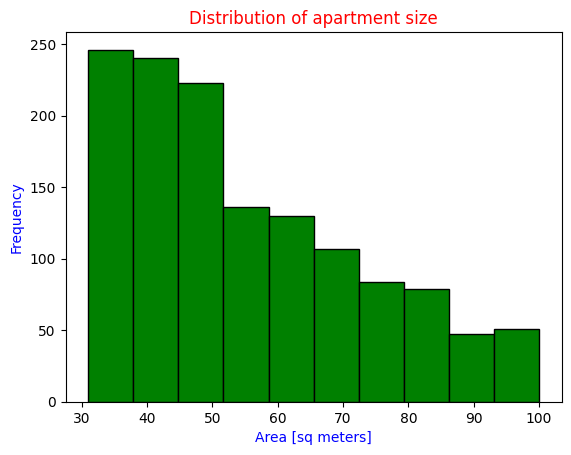

In [12]:
plt.hist(df['surface_covered_in_m2'],color='green',edgecolor='black')
plt.xlabel('Area [sq meters]',color='blue')
plt.ylabel('Frequency',color='blue')
plt.title('Distribution of apartment size',color='red');
# this unfiltered version of the graph shows that there are outliers in the data. 
# there are properties that ave very llarge as compared to the majourity of the properties

In [13]:
df['surface_covered_in_m2'].describe()

count    1343.000000
mean       55.076694
std        18.160427
min        31.000000
25%        40.000000
50%        50.000000
75%        68.500000
max       100.000000
Name: surface_covered_in_m2, dtype: float64

- we have a minimum of zero- which is wired because you do not sell apartments whose area is zero

- at he same time we have maximum of 62034 which is big .yet the mean is 97.8

- when u look at the median,  50% of the properties are 50m2 and below

- 75% of the properties are 73m2 and below then you have this large property that is 62034m2

- the mean is around 100 but the standard deviation(the spread) is 1500

        - It suggests one or more of the following:

         -The data has very high variability.

         -There may be extreme outliers (very large or very small values).

         -The mean may not be a good measure of the "typical" value, because a few extreme values can pull it away from where most of the data lies.

#### this shows that the data is spread out. it is skewed

In [14]:
""" we remove the outliers by picking the properties that are within the 90th and the 10th percentile"""

df['surface_covered_in_m2'].quantile([0.1,0.9])

0.1    35.0
0.9    84.0
Name: surface_covered_in_m2, dtype: float64

In [15]:
low,high= df['surface_covered_in_m2'].quantile([0.1,0.9])
print(f'{low}, {high}')

35.0, 84.0


In [16]:
low,high= df['surface_covered_in_m2'].quantile([0.1,0.9])
mask_area= df['surface_covered_in_m2'].between(low,high)
df[mask_area].head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42


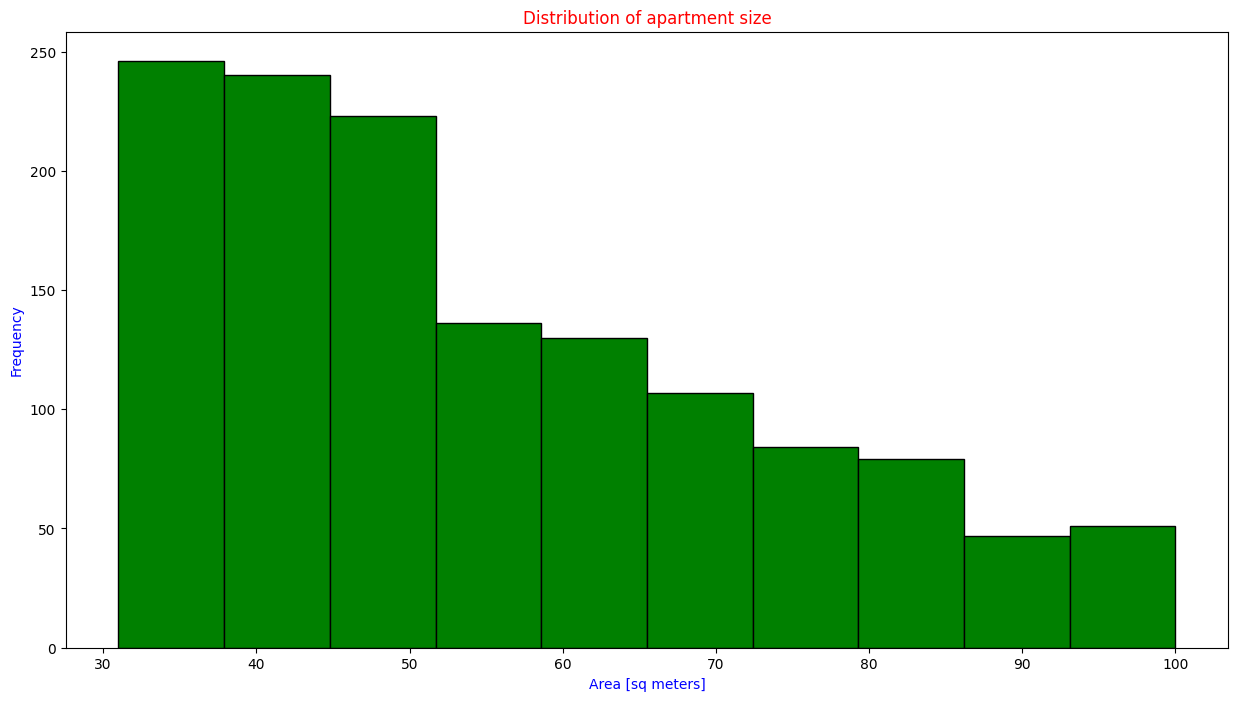

In [17]:
# using the data that is free of outliers we have this histogram
plt.figure(figsize=(15,8))
plt.hist(df['surface_covered_in_m2'],color='green',edgecolor='black')
plt.xlabel('Area [sq meters]',color='blue')
plt.ylabel('Frequency',color='blue')
plt.title('Distribution of apartment size',color='red');

now that the data is free of outliers, it is time to explore the relationship between appartment size and price

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 4 to 8604
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   1343 non-null   object 
 1   property_type               1343 non-null   object 
 2   place_with_parent_names     1343 non-null   object 
 3   lat-lon                     1300 non-null   object 
 4   price                       1343 non-null   float64
 5   currency                    1343 non-null   object 
 6   price_aprox_local_currency  1343 non-null   float64
 7   price_aprox_usd             1343 non-null   float64
 8   surface_total_in_m2         965 non-null    float64
 9   surface_covered_in_m2       1343 non-null   float64
 10  price_usd_per_m2            927 non-null    float64
 11  price_per_m2                1343 non-null   float64
 12  floor                       379 non-null    float64
 13  rooms                       1078 non-n

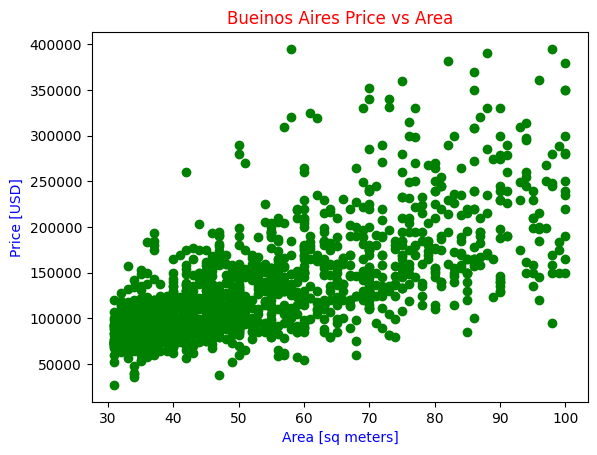

In [19]:
plt.scatter(x=df['surface_covered_in_m2'],y=df['price_aprox_usd'],color='green')
plt.xlabel('Area [sq meters]', color= 'blue')
plt.ylabel('Price [USD]',color='blue')
plt.title('Bueinos Aires Price vs Area', color= 'red');

In [20]:
correlation= df['surface_covered_in_m2'].corr(df['price_aprox_usd'])
print(correlation)

0.6868188329865075


the correlation between the price and the area is positive and it is above 0.5 meaning it is a moderately positive relationship

## linear model
linear models are about straight lines and are concerened with distance. it is all about trying to draw data that best fits the data ( in our case a that best describes the relationship between the price and size of the appartment). it is mainly about daawing the line that describes the data and minimizing the distance between the straight line and the data

## split
we have done importing then exploring now we are at split
a key part of model building, is separating your target( the ting you want to predict) from your features( the information your model will use to make predictions).
- target - the thing you want to predict
- features - the information your model wll use to make predictions

- The Feature matrix is always represented by X (upper case x).
feature matrix usually has many columns but for our case we will use onr column 
- Target vector is always represented by y ( lower case y)

Create a feature matrix named "X_train" which we will use to train the model. it should contain one feature only['surface_covered_in_m2]. the feature matrix should always be two dimensional

we split the data by creating the feature matrix(X) that will train the model and creating the target vector(y) that is the price(the thing we are predicting)

In [21]:
features= ['surface_covered_in_m2']  # IN THE FEATURE MATRIX it has to be a list bcz a matrix can have many columns and a matrix is 2 dimensional
X_train= df[features]
print(X_train.shape)
print(X_train.head())



(1343, 1)
    surface_covered_in_m2
4                    70.0
9                    42.0
29                   54.0
40                   42.0
41                   50.0


now we have the feature matrix- we can move on and make the target vector

we use the (_train) to indicate that this is out training data and not our testing data

In [22]:
target= 'price_aprox_usd'  # in the target vector , it has to be a string bcz a vector is one dimensional
y_train= df[target]
print(y_train.shape)

(1343,)


## Build model
#### baseline
the first step in building a model is baselining.

How will we know if the model is working well?

 the best way to answer the question is to see how a 'dumb' model would perform on the same data.

- the dumb model is called the naive/baseline model. it will only make one prediction( in out case it will predict the same price regardless of our apartment size)

- in order to create a baseline we need to ask ourselves if it is a regression problem or a classification problem
- if it is a regression model, then the target(the thing we want to predict) is a continuous value: eg the price of an apartment can range from a 0 to a big value
- if it is a classification problem, the end should be an answere of 2 options . eg either yes or no / clean or dirty (eg trying to predict whether two apartments will be sold in the next 6 months) you can either get the answer of a Yes or a No
- the baseline is reffered to as a "dumb/naive" model. the idea of a dumb or naive model is that it can only make one prediction nomatter the variable in question be it size or location, it will always come out with the same prediction
- in the case of a regression problem tie best prediction to make is to make the mean price the prediction

to set our baseline, we need to find out what is the mean value for our (y_train)

In [23]:
y_mean= y_train.mean()
y_mean

np.float64(135527.83871928515)

now that we have the mean, out naive model will predict the price of every apartment to be the mean. when it sees an apartment it will automatically assign the apartment the mean price regardless of the size


In [24]:
y_predict_baseline=y_mean    # we need a list , so we take y_mean and place it in a list
y_predict_baseline

np.float64(135527.83871928515)

In [25]:
y_predict_baseline= [y_mean] * len(y_train)  # it is a list but it has one prediction in it yet we want it to make the prediction over and over again and we want it to be as long as the dataset.so we multipy by the length of y_TRAIN
print(len(y_predict_baseline))
print(len(y_predict_baseline)==len(y_train))
y_predict_baseline[:5]


1343
True


[np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515)]

we need to find out how the baseline model performs .

we evalueate it bu plotting it above the scatter plot above

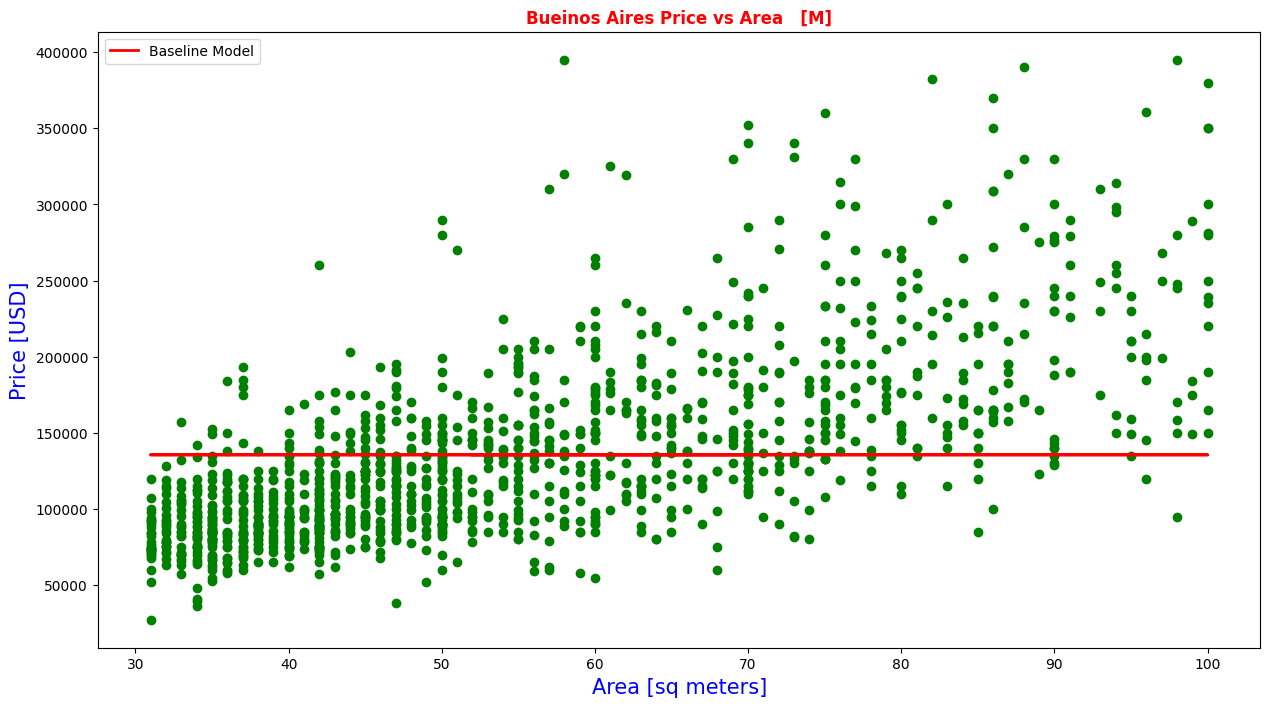

In [26]:
plt.figure(figsize=(15,8))
plt.plot(X_train,y_predict_baseline,color='red',linewidth=2,label='Baseline Model')
plt.scatter(X_train,y_train,color='green')
plt.title('Bueinos Aires Price vs Area   [M]', color= 'red',fontweight='bold')
plt.xlabel('Area [sq meters]',color='blue',fontsize=15)
plt.ylabel('Price [USD]',color='blue',fontsize=15)
plt.legend();


from this, we can see that no matter the size of the apartment, the model will always predict the same amount which is the mean

however this does not follow the trend  of the data bcz we can see that the price tends to increase as the area increases. so we need to evaluate mathematically

<Figure size 1500x800 with 0 Axes>

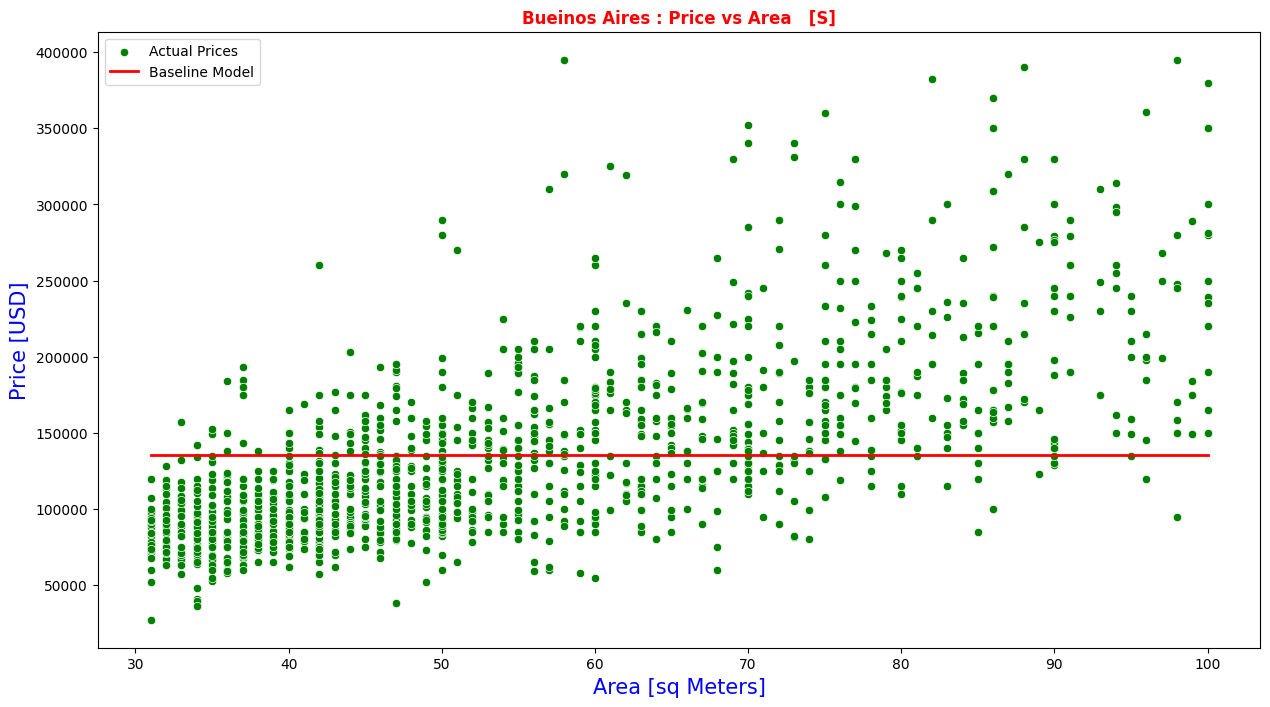

In [27]:
plt.figure(figsize=(15,8))

plot_df = pd.DataFrame({
    'Area': X_train['surface_covered_in_m2'],
    'Actual Price': y_train,
    'Baseline Prediction': y_predict_baseline
})

plt.figure(figsize=(15, 8))

sns.scatterplot(
    data=plot_df,
    x='Area',
    y='Actual Price',
    color='green',
    label='Actual Prices'
)

sns.lineplot(
    data=plot_df,
    x='Area',
    y='Baseline Prediction',
    color='red',
    linewidth=2,
    label='Baseline Model'
)

plt.xlabel(
    'Area [sq Meters]',
    color='blue',
    fontsize=15)

plt.ylabel(
    'Price [USD]',
    color='blue',
    fontsize=15)

plt.title(
    'Bueinos Aires : Price vs Area   [S]',
    color='red',
    fontweight='bold')

plt.legend();

In [28]:
print(X_train.shape)
print(y_train.shape)

print(type(X_train))
print(type(y_train))

(1343, 1)
(1343,)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [29]:
X_train.values[:6]

array([[70.],
       [42.],
       [54.],
       [42.],
       [50.],
       [74.]])

we need to evaluate this mathematically
#### Baseline Mean Absolute Error
- this is a performance metric that tells you how far your predictions are from the true value

In [30]:
mae_baseline= mean_absolute_error(y_train,y_predict_baseline)

print(f'mean apartment price {round(y_mean,2)}')
print(f'Baseline Mean absolute error: {round(mae_baseline,2)}')

mean apartment price 135527.84
Baseline Mean absolute error: 45199.46


wwhat this means is that:    
- if i guessed the price of every apartment to be  $153,527 , on average my predictions will be off by $45,199
- therefore for our model to be usefull we need a mean absolute error that is less than  $45,199

## iterate
the next steps building the model, training it, evaluating it and then repeating the process till you are happy with the model's performance.
- first : creating the model. use linear regression

In [31]:
# step 1 : instantiate the model
model= LinearRegression()

In [32]:
# step 2 : train the model /  fit the model into our data
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Evaluate
next we evaluate. we see how well it makes predictions for data we saw during training. we therefor have it predict the price of houses we have in our training data

In [33]:
# step 3 : predict 
y_predict_training= model.predict(X_train)
y_predict_training[:6]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668, 178164.36276334])

since we have our predictions, we use them to asses our model's performance.

we use the mean absolute error to do this since we used it with the baseline model


In [34]:
mae_training= mean_absolute_error(y_train,y_predict_training)

print(f'Training  Mean absolute Error {round(mae_training,2)}')

Training  Mean absolute Error 31248.26


the MAE of the training model is lower than that of the baseline model. this shows that the model will work. now we need to test the model against new data

In [35]:
X_test= pd.read_csv(r"C:\Users\Peace\OneDrive\WP projects\HOUSING IN BUENOS AIRES 2\bueinos-aires-test-features - Sheet1.csv")[features] # imports the test data and only pics the features[in this case (surface_covered-in_m2)]
y_predict_test=pd.Series(model.predict(X_test))
y_predict_test.head()

0    117330.058901
1    135355.037823
2     88039.468152
3     88039.468152
4    106064.447074
dtype: float64

## communicating the result
since we deal with a linear model, the best way to communicate the results is to use an equation
y=mx+c
- we need to find the y-intercept   the  (c)
#### getting the model intercept

In [36]:
intercept= round(model.intercept_,2)
print(f' Model Intercept : {round(intercept,2)}')

 Model Intercept : 11433.31


#### getting the coefficient (slope/gradient)

In [37]:
coefficient = round(model.coef_[0],2)  # we do not want it in a list so we do [0]
print(f'Model coefficient(slope) for "surface_covered_in_m2" : {coefficient}')

Model coefficient(slope) for "surface_covered_in_m2" : 2253.12


now that we have the intercept and the coefficient we have to make the equation

In [38]:
print(f'apartment_price = {intercept} + {coefficient} * surface_covered')

apartment_price = 11433.31 + 2253.12 * surface_covered


#### visually 

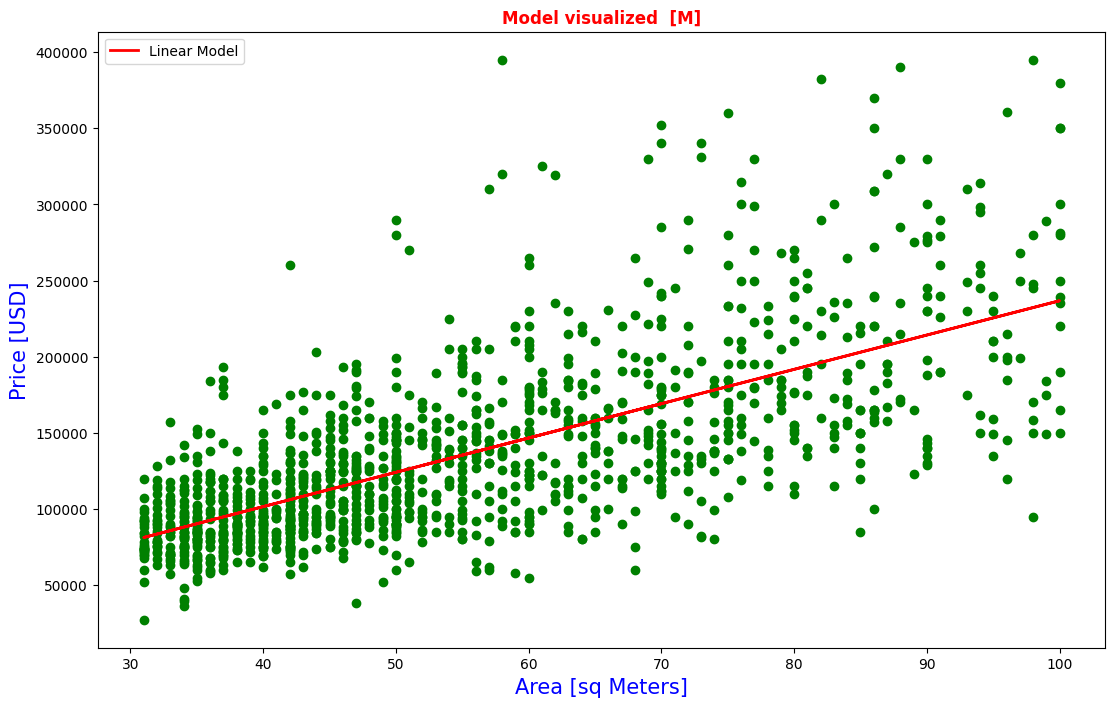

In [39]:
plt.figure(figsize=(13,8))
plt.plot(X_train,model.predict(X_train),color='red',linewidth=2,label='Linear Model')
plt.scatter(X_train,y_train,color='green')
plt.xlabel('Area [sq Meters]',color='blue',fontsize=15)
plt.ylabel('Price [USD]',color='blue',fontsize=15)
plt.title('Model visualized  [M]',color='red',fontweight='bold')
plt.legend();



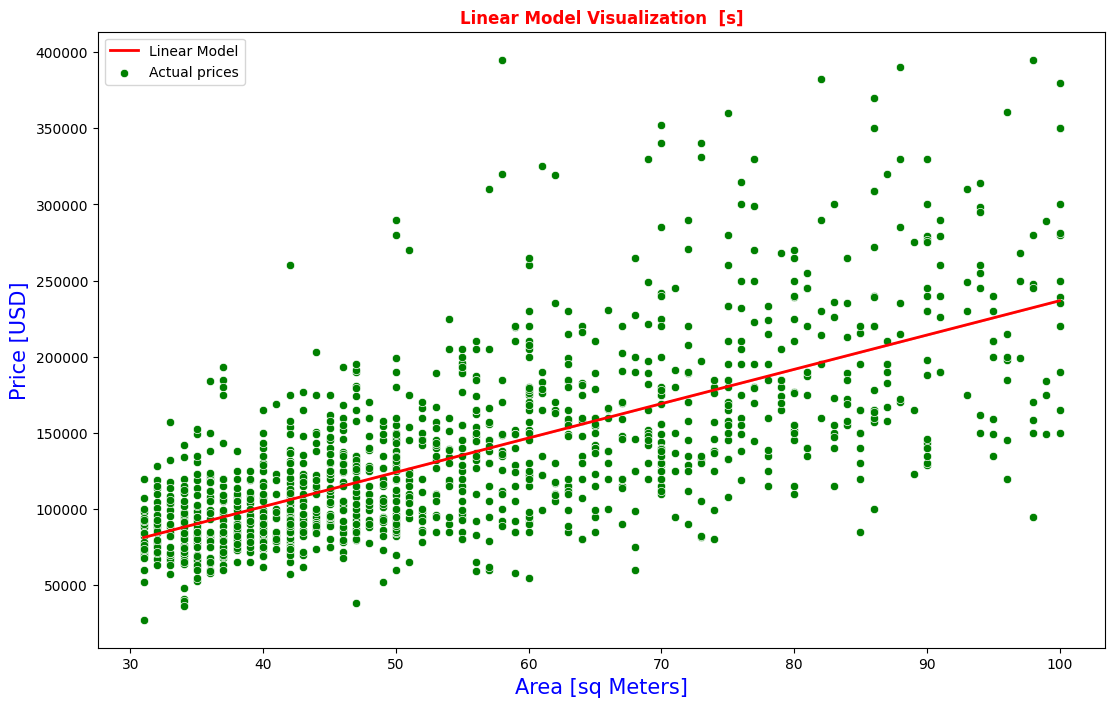

In [40]:
plt.figure(figsize=(13,8))

final_df= pd.DataFrame({
    'area' : X_train['surface_covered_in_m2'],
    'actual_price' : y_train,
    'model' : y_predict_training
    })

sns.lineplot(
    data=final_df,
    x='area',
    y='model',
    color='red',
    linewidth=2,
    label='Linear Model'
)

sns.scatterplot(
    data=final_df,
    x='area',
    y='actual_price',
    color='green',
    label='Actual prices'
)

plt.title(
    'Linear Model Visualization  [s]',
    fontweight='bold',
    color='red'
)

plt.xlabel(
    'Area [sq Meters]',
    color='blue',
    fontsize=15)

plt.ylabel(
    'Price [USD]',
    color='blue',
    fontsize=15)

plt.legend();

In [41]:
import joblib
joblib.dump(model,'model.pkl')

['model.pkl']